<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [2]:
# Check for GPU

In [5]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device-agnostic code
device = torch.device("cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")

2.11.0+cu130


/home/eric.musliner/Documents/dev/pytorch-workbooks/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. What are 3 areas in industry where computer vision is currently being used?

1.
2.
3.

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [6]:
import torch
from torch import nn
import torchvision
from torch.nn import CrossEntropyLoss
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

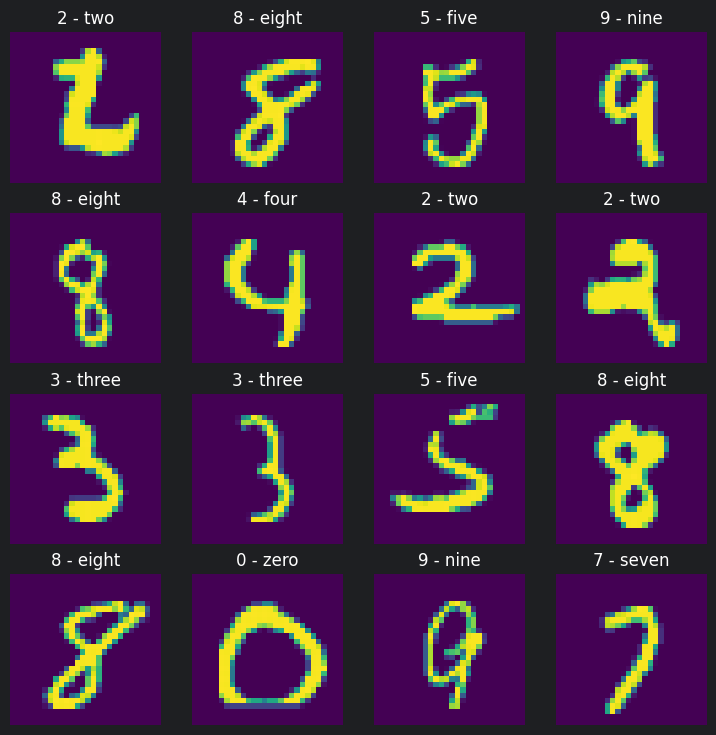

In [7]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(9, 9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze())
    plt.title(train_data.classes[label])
    plt.axis('off')

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# turn datasets into iterable (datasets)
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_data.classes
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x77172ea5b390>,
 <torch.utils.data.dataloader.DataLoader at 0x77173571bce0>)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [9]:
class MNISTModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

model = MNISTModel(input_shape=1, hidden_units=10, output_shape=len(class_names)).to(device)

    ## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [10]:
from timeit import default_timer as timer, default_timer


def print_train_time(start: float, end: float, device: torch.device = None) -> float:
    """ prints difference between start time and end time """
    elapsed = end - start
    print(f"Training time on {device}: {elapsed:.3f} seconds")
    return elapsed

start_time = timer()
# some code...
end_time = timer()
print_train_time(start_time, end_time, device=torch.device("cpu"))

Training time on cpu: 0.000 seconds


9.413000952918082e-06

In [11]:
from tqdm.auto import tqdm

torch.manual_seed(42)

def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device,
):
    """
    Perform training with model trying to learn on data loader.

    :param model:
    :param train_dataloader:
    :param loss_fn:
    :param optimizer:
    :param accuracy_fn:
    :param device:
    :return:
    :rtype:
    """
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        # Forward pass
        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate train loss
        train_acc += accuracy_fn(y, y_pred.argmax(dim=1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Avg training loss per batch per epoch
    # Divide total train loss by length of train data loader
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%\n")

def test_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device,
):
    """
    Perform testing with model trying to learn on data loader.

    :param model:
    :param data_loader:
    :param loss_fn:
    :param optimizer:
    :param accuracy_fn:
    :param device:
    :return:
    :rtype:
    """

    # Testing
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)

            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
        # Calculate the test loss/acc average per batch
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

    print(f"\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


In [12]:
from src.helper_functions import accuracy_fn

torch.manual_seed(42)

from timeit import default_timer as timer

epochs = 5

loss_fn = CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

device = torch.device("cpu")
train_time_start_cpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---------")
    train_step(model=model,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

    test_step(model=model,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_time_end_cpu = timer()
total_train_time_cpu = print_train_time(train_time_start_cpu, train_time_end_cpu, device)
print(total_train_time_cpu)

# Setup device-agnostic code
device = torch.device("cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")

train_time_start_gpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---------")
    train_step(model=model,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

    test_step(model=model,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

train_time_end_gpu = timer()
total_train_time_gpu = print_train_time(train_time_start_gpu, train_time_end_gpu, device)
print(total_train_time_gpu)



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
---------
Train loss: 0.45683 | Train accuracy: 84.00%


Test loss: 0.06516 | Test accuracy: 97.79%

Epoch 1
---------
Train loss: 0.07471 | Train accuracy: 97.63%


Test loss: 0.05053 | Test accuracy: 98.44%

Epoch 2
---------
Train loss: 0.05770 | Train accuracy: 98.19%


Test loss: 0.04645 | Test accuracy: 98.52%

Epoch 3
---------
Train loss: 0.04939 | Train accuracy: 98.42%


Test loss: 0.04719 | Test accuracy: 98.41%

Epoch 4
---------
Train loss: 0.04354 | Train accuracy: 98.64%


Test loss: 0.03900 | Test accuracy: 98.81%

Training time on cpu: 80.404 seconds
80.4041234230026


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
---------
Train loss: 0.03973 | Train accuracy: 98.74%


Test loss: 0.04739 | Test accuracy: 98.53%

Epoch 1
---------
Train loss: 0.03597 | Train accuracy: 98.87%


Test loss: 0.04256 | Test accuracy: 98.62%

Epoch 2
---------
Train loss: 0.03330 | Train accuracy: 98.94%


Test loss: 0.03785 | Test accuracy: 98.75%

Epoch 3
---------
Train loss: 0.03243 | Train accuracy: 98.93%


Test loss: 0.04178 | Test accuracy: 98.78%

Epoch 4
---------
Train loss: 0.03014 | Train accuracy: 99.00%


Test loss: 0.03596 | Test accuracy: 98.87%

Training time on cpu: 80.285 seconds
80.28505905200291


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [13]:
device = torch.device("cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")

def make_predictions(model: torch.nn.Module, data:list, device: torch.device = device):
    pred_probs = []
    model.to(device)
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare the sample ( add batch dimension and pass to target device)
            sample = torch.unsqueeze(sample, dim=0).to(device)
            # Forward pass (model outputs raw logits)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Get pred_prob off gpu for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

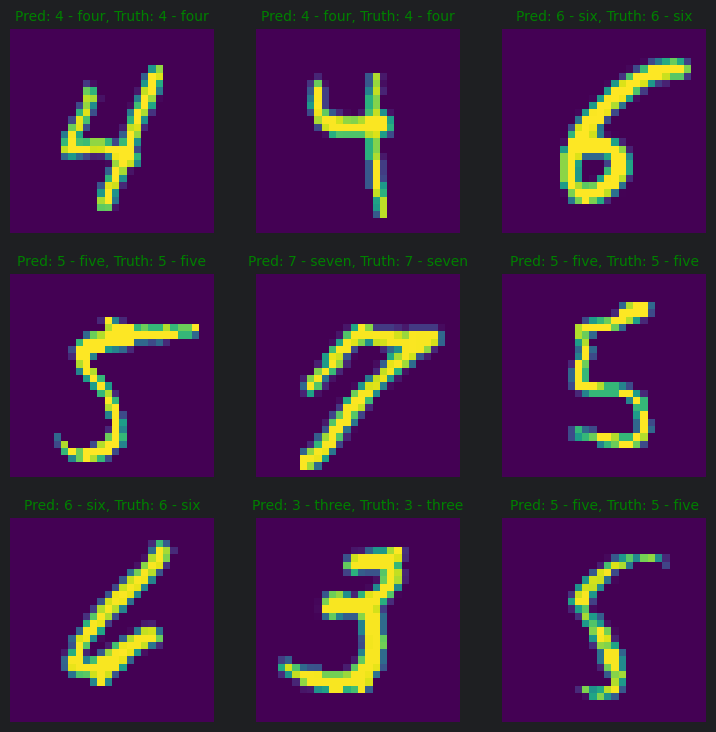

In [14]:
import random

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

pred_probs = make_predictions(model, test_samples, device)

# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)

plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
    # Create subplot
    plt.subplot(nrows, ncols, i+1)

    # plot target image
    plt.imshow(sample.squeeze())

    # Find prediction label in text form
    pred_label = class_names[pred_classes[i]]

    # Get truth label
    truth_label = class_names[test_labels[i]]

    # Create title for the plot
    title_text = f"Pred: {pred_label}, Truth: {truth_label}"

    # Check for equality between pred and truth and chnge color of title text
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, color="green")
    else:
        plt.title(title_text, fontsize=10, color="red")
    plt.axis(False)

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

device: cpu


Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([7, 2])
10000


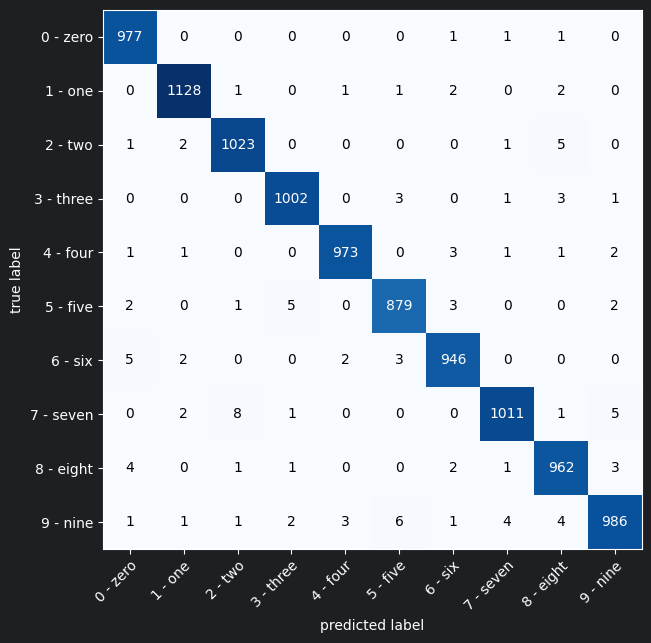

In [15]:
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
y_true = []
model.eval()
print(f"device: {device}")
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions..."):
        X, y = X.to(device), y.to(device)

        y_logit = model(X)
        y_pred = y_logit.argmax(dim=1)
        y_preds.append(y_pred.cpu())
        y_true.append(y.cpu())

y_pred_tensor = torch.cat(y_preds)
y_true_tensor = torch.cat(y_true)
print(y_pred_tensor[:2])
print(len(y_pred_tensor))

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=y_true_tensor)

# plot confusion matrix

fig, ax = plot_confusion_matrix(
    confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7),
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [16]:
rand = torch.randn(size=(1, 3, 64, 64))

conv_layer = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=2, stride=1, padding=0)
conv_output = conv_layer(rand)
print(conv_output.shape)


torch.Size([1, 10, 63, 63])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [17]:
# Download FashionMNIST train & test
from torchvision import datasets
from torchvision import transforms

fashion_mnist_train = datasets.FashionMNIST(root="./data",
                                            download=True,
                                            train=True,
                                            transform=transforms.ToTensor())

fashion_mnist_test = datasets.FashionMNIST(root="./data",
                                           train=False,
                                           download=True,
                                           transform=transforms.ToTensor())

len(fashion_mnist_train), len(fashion_mnist_test)

(60000, 10000)

In [18]:
# Get class names of Fashion MNIST
fashion_mnist_class_names = fashion_mnist_train.classes
fashion_mnist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [19]:
# Turn datasets into data loaders
from torch.utils.data import DataLoader

fashion_mnist_train_dataloader = DataLoader(fashion_mnist_train,
                                            batch_size=32,
                                            shuffle=True)

fashion_mnist_test_dataloader = DataLoader(fashion_mnist_test,
                                           batch_size=32,
                                           shuffle=False)

len(fashion_mnist_train_dataloader), len(fashion_mnist_test_dataloader)

(1875, 313)

In [22]:
# model_2 is the same architecture as MNIST_model
model_2 = MNISTModel(input_shape=1,
                      hidden_units=10,
                      output_shape=10).to(device)
model_2

MNISTModel(
  (block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [23]:
# Setup loss and optimizer
from torch import nn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.01)

In [25]:
# Setup metrics
from tqdm.auto import tqdm
from torchmetrics import Accuracy

acc_fn = Accuracy(task = 'multiclass', num_classes=len(fashion_mnist_class_names)).to(device)

for epoch in tqdm(range(epochs)):
    print(f"Epoch {epoch}\n---------")
    train_step(model=model_2,
               data_loader=fashion_mnist_train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)

    test_step(model=model_2,
              data_loader=fashion_mnist_test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0
---------
Train loss: 1.24282 | Train accuracy: 55.76%


Test loss: 0.69128 | Test accuracy: 72.79%

Epoch 1
---------
Train loss: 0.54107 | Train accuracy: 80.38%


Test loss: 0.48585 | Test accuracy: 82.36%

Epoch 2
---------
Train loss: 0.44096 | Train accuracy: 84.25%


Test loss: 0.42774 | Test accuracy: 84.64%

Epoch 3
---------
Train loss: 0.39903 | Train accuracy: 85.62%


Test loss: 0.39161 | Test accuracy: 86.29%

Epoch 4
---------
Train loss: 0.37034 | Train accuracy: 86.71%


Test loss: 0.39016 | Test accuracy: 86.44%



In [26]:
# Make predictions
test_preds = []
model_2.eval()
with torch.inference_mode():
    for X_test, y_test in tqdm(fashion_mnist_test_dataloader):
        y_logits = model_2(X_test.to(device))
        y_pred_probs = torch.softmax(y_logits, dim=1)
        y_pred_labels = torch.argmax(y_pred_probs, dim=1)
        test_preds.append(y_pred_labels)
test_preds = torch.cat(test_preds).cpu()
test_preds[:10], len(test_preds)

  0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), 10000)

In [27]:
# Get wrong prediction indexes
import numpy as np
wrong_pred_indexes = np.where(test_preds != fashion_mnist_test.targets)[0]
len(wrong_pred_indexes)

1356

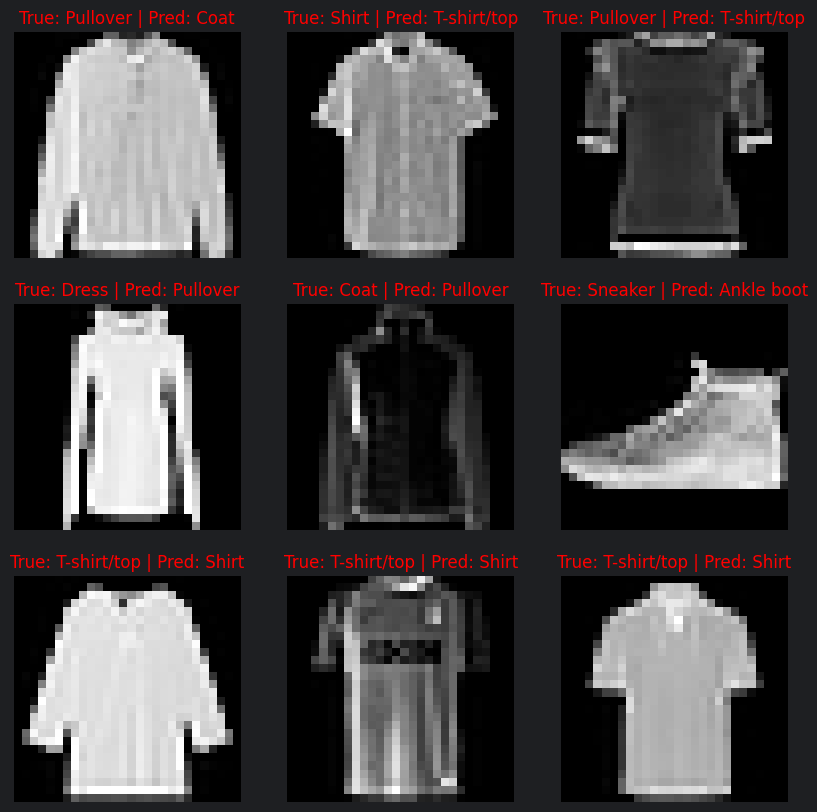

In [30]:
# Select 9 random wrong predictions
import random
random_selection = random.sample(list(wrong_pred_indexes), k=9)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_selection):
  true_label = fashion_mnist_class_names[fashion_mnist_test[idx][1]]
  pred_label = fashion_mnist_class_names[test_preds[idx]]

  # Plot the wrong prediction with its original label
  plt.subplot(3, 3, i+1)
  plt.imshow(fashion_mnist_test[idx][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r")
  plt.axis(False);